> Технический прогон 14.09.2026: все расчётные ячейки этого отчёта выполнены последовательно в чистом ядре на указанных в коде исходных результатах. FEM заново не решалась. Исполнение отчёта не повышает доказательный статус исходного исследования.

# Контрольная сетка (smoke)
Контрольная сетка (smoke); все заданные позы учтены. Набор: full_pose_scan_fullscan_smoke05; проверено SHA256: 87 файлов. Центров: 4; углов: 3; поз: 12/12. Evaluated: 4; invalid_geometry: 8; отсутствуют: 0. Фиксированные ρ₁=5.5521664546649, ρ₂=30.706946809082 Ом·м. Геометрический QC: подтверждён в summary. Статус: numerical_candidate_not_validated. Полнота перебора не означает физическую или экспериментальную валидацию модели.

![Карта](full_scan.png)

[Открыть интерактивный отчёт](full_scan.html)

## Повторное чтение исходного smoke-расчёта

Таблицы ниже заново читаются из серии `fullscan_smoke05`; проверяются контрольные суммы её контракта. Это небольшой технический тест сканирования позы, а не полный поиск и не физическая валидация. Прежнее геометрическое представление сохранено отдельно, чтобы HTML-экспорт ноутбука не вкладывал сам себя.

Проверено 12 поз; рассчитаны 4, отклонены по геометрии 8. Минимальная среднеквадратичная невязка: 7.2879 Ом.

,centre_index,phi_deg,status,rmse_ohm,failure_code
0,1,-20.0,invalid_geometry,NaN,trkg4:electrodeDiagnostics
1,1,2.5,evaluated,7.903566,NaN
2,1,20.0,invalid_geometry,NaN,trkg4:electrodeDiagnostics
3,2,-20.0,invalid_geometry,NaN,trkg4:electrodeDiagnostics
4,2,2.5,evaluated,11.537968,NaN
5,2,20.0,invalid_geometry,NaN,trkg4:electrodeDiagnostics
6,3,-20.0,invalid_geometry,NaN,trkg4:electrodeDiagnostics
7,3,2.5,evaluated,7.287878,NaN
8,3,20.0,invalid_geometry,NaN,trkg4:electrodeDiagnostics
9,4,-20.0,invalid_geometry,NaN,trkg4:electrodeDiagnostics


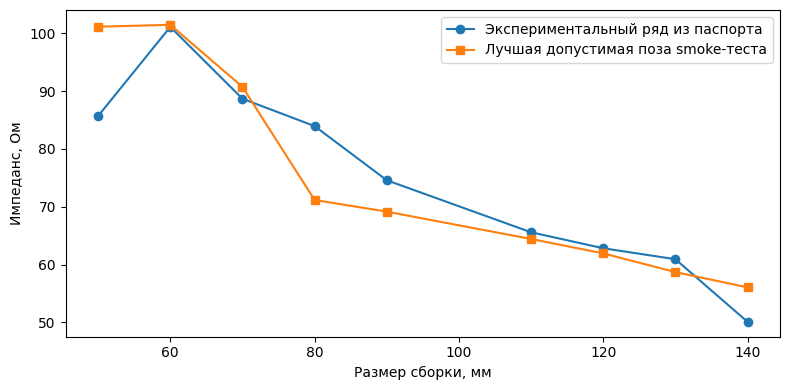

In [2]:
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, IFrame
repo=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'MATLAB_TRKG4_real_subjects/run_pipeline.m').is_file())
run=repo/'MATLAB_TRKG4_real_subjects/output/full_pose_scan_fullscan_smoke05'
contract=json.loads((run/'result_contract.json').read_text(encoding='utf-8-sig'))
assert contract['complete']
for item in contract['artifacts']:
    path=(run/item['path']).resolve()
    assert path.is_relative_to(run.resolve())
    with path.open('rb') as stream:
        assert hashlib.file_digest(stream,'sha256').hexdigest()==item['sha256'],item['path']
summary=json.loads((run/'summary.json').read_text(encoding='utf-8-sig'))
assert summary['result_tag']=='fullscan_smoke05'
assert summary['fingerprint']==contract['fingerprint']
poses=pd.read_csv(run/'poses.csv')
centres=pd.read_csv(run/'centre_results.csv')
valid=poses.loc[poses.status=='evaluated'].copy()
sizes=np.asarray(summary['experiment']['L_mm'])
observed=np.asarray(summary['experiment']['Z_ohm'])
predicted=valid[[f'Z_L{int(size):03d}_ohm' for size in sizes]].to_numpy()
rmse=np.sqrt(np.mean((predicted-observed)**2,axis=1))
assert np.allclose(rmse,valid.rmse_ohm,rtol=1e-8)
best=valid.loc[valid.rmse_ohm.idxmin()]
assert np.isclose(best.rmse_ohm,summary['best']['rmse_ohm'])
display(Markdown(f"Проверено {len(poses)} поз; рассчитаны {len(valid)}, отклонены по геометрии {(poses.status=='invalid_geometry').sum()}. Минимальная среднеквадратичная невязка: {best.rmse_ohm:.4f} Ом."))
display(poses[['centre_index','phi_deg','status','rmse_ohm','failure_code']])
fig,ax=plt.subplots(figsize=(8,4))
ax.plot(sizes,observed,'o-',label='Экспериментальный ряд из паспорта')
ax.plot(sizes,best[[f'Z_L{int(size):03d}_ohm' for size in sizes]].to_numpy(dtype=float),'s-',label='Лучшая допустимая поза smoke-теста')
ax.set(xlabel='Размер сборки, мм',ylabel='Импеданс, Ом')
ax.legend();fig.tight_layout();plt.show()


## Сохранённое геометрическое представление

Это исходная визуализация той же серии, а не новый FEM-расчёт. Численная проверка выше выполнена отдельно по CSV и JSON.

In [3]:
view=run/'report/full_scan_geometry_view.html'
assert hashlib.sha256(view.read_bytes()).hexdigest()=='ec5b75c08c2c1cdb13f358ad0145f23e03ef814f29dc1c0d3ef9144f0a0bd12c'
display(IFrame('full_scan_geometry_view.html',width='100%',height=1100))